In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

# Forecasting de Demanda Eléctrica Horaria

## Proyecto de Ciencia de Datos aplicado al consumo eléctrico

Este proyecto tiene como objetivo analizar y predecir la demanda eléctrica horaria utilizando datos históricos del sistema PJM Interconnection, una organización regional de transmisión eléctrica en Estados Unidos.

El dataset utilizado corresponde a **Hourly Energy Consumption**, disponible en Kaggle, el cual contiene registros horarios de consumo eléctrico medidos en megawatts para distintas zonas del mercado PJM.

El propósito del proyecto es construir un flujo completo de análisis de series de tiempo, desde la exploración inicial de los datos hasta la generación de modelos predictivos capaces de anticipar la demanda eléctrica futura.

## 1. Contexto del problema

La demanda eléctrica es una variable crítica para la planificación, operación y gestión de los sistemas energéticos. 

Una predicción adecuada del consumo permite anticipar períodos de alta demanda, mejorar la asignación de recursos, reducir riesgos operacionales y apoyar la toma de decisiones en generación, transmisión y distribución eléctrica.

En este proyecto se trabajará con datos horarios de consumo eléctrico, lo que permite capturar patrones de comportamiento asociados a:

- Horas del día.
- Días de la semana.
- Meses del año.
- Estacionalidad anual.
- Eventos de alta demanda o peak demand.

Este tipo de problema corresponde a un caso clásico de **forecasting de series de tiempo**, ampliamente utilizado en sectores como energía, retail, logística, finanzas y planificación operacional.

## 2. Objetivo del proyecto

El objetivo principal de este proyecto es desarrollar un modelo predictivo para estimar la demanda eléctrica horaria futura a partir de patrones históricos de consumo.

### Objetivos específicos

1. Cargar y explorar el dataset de consumo eléctrico horario.
2. Analizar la estructura temporal de la serie.
3. Identificar patrones horarios, diarios, semanales y mensuales.
4. Detectar períodos de alta demanda eléctrica.
5. Preparar variables temporales para modelamiento predictivo.
6. Entrenar modelos base de forecasting.
7. Comparar el desempeño de distintos enfoques predictivos.
8. Generar conclusiones orientadas a un contexto de negocio energético.

In [2]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuración general de visualización
plt.rcParams['figure.figsize'] = (14, 5)

En esta etapa se importan las librerías necesarias para el análisis inicial del proyecto.

Se utilizará `pandas` para la manipulación de datos, `numpy` para operaciones numéricas y `matplotlib` para la visualización de la serie temporal. También se incorporan métricas de evaluación que serán utilizadas posteriormente para comparar modelos predictivos.

## 3. Revisión de archivos disponibles en Kaggle

Antes de cargar un archivo específico, se inspecciona el directorio de entrada de Kaggle para identificar todos los archivos disponibles dentro del dataset.

Esto es importante porque el dataset contiene múltiples archivos CSV asociados a distintas zonas eléctricas del sistema PJM.

In [3]:
# ============================================================
# 2. EXPLORACIÓN DE ARCHIVOS DISPONIBLES
# ============================================================

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/robikscube/hourly-energy-consumption/est_hourly.paruqet
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DOM_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/EKPC_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DUQ_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DAYTON_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJM_Load_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/NI_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/FE_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/COMED_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/AEP_hourly.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/pjm_hourly_est.csv
/kaggle/input/datasets/robikscube/hourly-energy-consumption/DEOK_hourly.csv
/kaggl

El dataset contiene distintos archivos asociados a zonas o subconjuntos del sistema eléctrico PJM. 

Para desarrollar una primera versión controlada del proyecto, se seleccionará inicialmente el archivo `PJME_hourly.csv`, correspondiente a una zona específica del mercado PJM.

Trabajar primero con una sola serie permite construir una metodología clara de análisis y modelamiento, la cual posteriormente puede ser extendida a otras zonas eléctricas.

## 4. Carga del dataset principal

Para esta primera etapa del proyecto se utilizará el archivo `PJME_hourly.csv`.

Este archivo contiene registros horarios de consumo eléctrico en megawatts. Cada observación representa el nivel de demanda eléctrica registrado en una fecha y hora específica.

In [4]:
# ============================================================
# 3. CARGA DEL DATASET PRINCIPAL
# ============================================================

path = '/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv'

df = pd.read_csv(path)

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


La vista inicial del dataset permite confirmar que la información está estructurada en dos columnas principales:

- `Datetime`: fecha y hora del registro.
- `PJME_MW`: consumo eléctrico medido en megawatts.

Esta estructura es adecuada para construir una serie de tiempo univariada, donde la variable objetivo será el consumo eléctrico horario.

## 5. Exploración inicial del dataset

En esta sección se revisan las dimensiones del dataset, los tipos de datos, las columnas disponibles y la presencia de valores nulos.

Este paso es fundamental para detectar problemas iniciales de calidad de datos antes de avanzar hacia el análisis temporal y el modelamiento predictivo.

In [5]:
# ============================================================
# 4. EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

Dimensiones del dataset:
(145366, 2)

Columnas disponibles:
Index(['Datetime', 'PJME_MW'], dtype='object')

Tipos de datos:
Datetime     object
PJME_MW     float64
dtype: object

Valores nulos por columna:
Datetime    0
PJME_MW     0
dtype: int64

Primeras filas:


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0



Últimas filas:


,Datetime,PJME_MW
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0
145365,2018-01-02 00:00:00,38608.0


La exploración inicial permite verificar la cantidad de registros disponibles, el tipo de dato de cada columna y la existencia de valores nulos.

Dado que se trata de una serie temporal horaria, es especialmente importante revisar que la columna de fecha sea convertida correctamente a formato `datetime` y que los registros queden ordenados cronológicamente.

## 6. Preparación de la serie temporal

Para trabajar correctamente con series de tiempo, la columna `Datetime` debe convertirse a formato temporal y utilizarse como índice del dataframe.

Esto permitirá realizar operaciones temporales como agregaciones por hora, día, semana, mes y año, además de facilitar la construcción de variables predictivas basadas en el calendario.

In [6]:
# ============================================================
# 5. PREPARACIÓN DE LA COLUMNA DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(df['Datetime'])

df = df.sort_values('Datetime')

df = df.set_index('Datetime')

df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [7]:
# ============================================================
# 6. REVISIÓN DEL RANGO TEMPORAL
# ============================================================

print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())
print("Cantidad total de registros:", len(df))

Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00
Cantidad total de registros: 145366


Una vez convertida la columna `Datetime`, el dataset queda estructurado como una serie temporal indexada por fecha y hora.

Esto facilita el análisis cronológico de la demanda eléctrica y permite identificar el rango histórico cubierto por los datos.

## 7. Visualización general del consumo eléctrico

La primera visualización de la serie completa permite observar el comportamiento general de la demanda eléctrica a lo largo del tiempo.

Este gráfico ayuda a identificar visualmente patrones de estacionalidad, cambios de nivel, períodos de alta variabilidad y posibles eventos extremos de consumo.

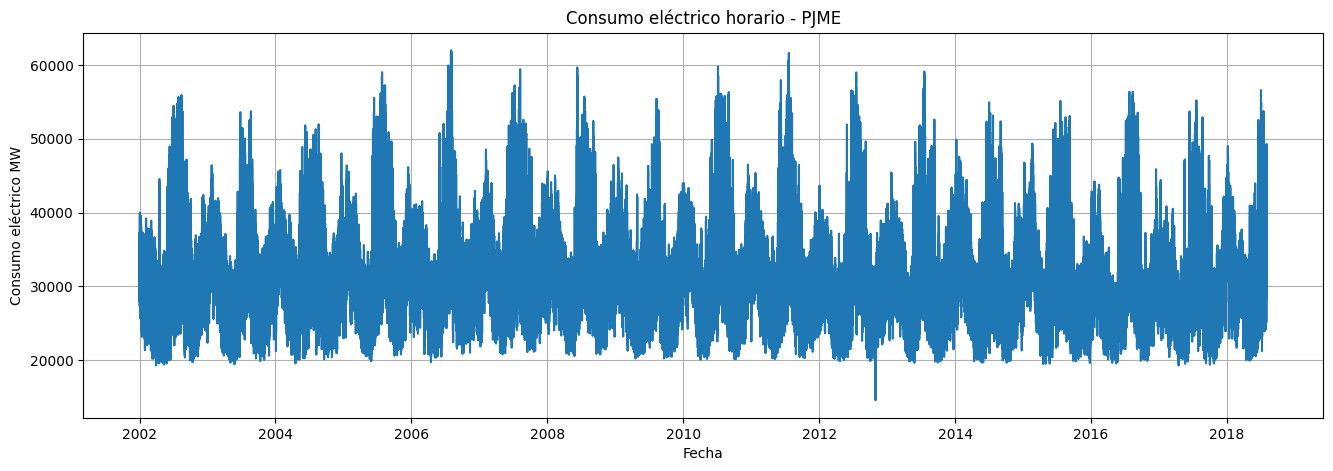

In [8]:
# ============================================================
# 7. VISUALIZACIÓN GENERAL DE LA SERIE TEMPORAL
# ============================================================

plt.figure(figsize=(16, 5))
plt.plot(df.index, df['PJME_MW'])
plt.title('Consumo eléctrico horario - PJME')
plt.xlabel('Fecha')
plt.ylabel('Consumo eléctrico MW')
plt.grid(True)
plt.show()

La serie muestra una alta frecuencia de observaciones debido a que los datos son horarios.

A simple vista se pueden observar fluctuaciones recurrentes en la demanda eléctrica, lo que sugiere la presencia de patrones temporales asociados al comportamiento diario, semanal y estacional del consumo.

## 8. Creación de variables temporales

Para analizar y modelar una serie de tiempo horaria, es necesario extraer información del calendario a partir del índice temporal.

Estas variables permiten capturar patrones recurrentes del consumo eléctrico asociados a distintos niveles de agregación temporal, como la hora del día, el día de la semana, el mes y el año.

En esta etapa se crearán variables temporales que posteriormente serán utilizadas tanto para el análisis exploratorio como para el modelamiento predictivo.

In [9]:
# ============================================================
# 8. CREACIÓN DE VARIABLES TEMPORALES
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,1,1,1,1,2002


Las variables temporales creadas permiten descomponer el comportamiento de la demanda eléctrica en distintas dimensiones de tiempo.

Esto es especialmente relevante porque el consumo eléctrico no suele comportarse de manera aleatoria, sino que responde a rutinas humanas, ciclos laborales, condiciones climáticas y patrones estacionales.

## 9. Validación y tratamiento de continuidad temporal

Dado que el dataset corresponde a datos horarios, se espera que entre un registro y otro exista una diferencia de una hora.

La validación inicial detectó timestamps duplicados y algunas fechas faltantes dentro del rango histórico. En problemas de forecasting, estos aspectos deben tratarse antes de entrenar modelos predictivos, ya que muchos algoritmos asumen observaciones igualmente espaciadas en el tiempo.

Para corregir la serie, se consolidan los duplicados utilizando el promedio y posteriormente se reconstruye el índice horario completo, imputando los valores faltantes mediante interpolación temporal.

In [10]:
# ============================================================
# 9. VALIDACIÓN DE DUPLICADOS TEMPORALES
# ============================================================

duplicated_dates = df.index.duplicated().sum()

print("Cantidad de fechas duplicadas:", duplicated_dates)

if duplicated_dates > 0:
    print("\nFechas duplicadas detectadas:")
    display(df[df.index.duplicated(keep=False)].sort_index())

Cantidad de fechas duplicadas: 4

Fechas duplicadas detectadas:


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2014-11-02 02:00:00,23755.0,2,6,2,306,44,11,4,2014
2014-11-02 02:00:00,22935.0,2,6,2,306,44,11,4,2014
2015-11-01 02:00:00,21567.0,2,6,1,305,44,11,4,2015
2015-11-01 02:00:00,21171.0,2,6,1,305,44,11,4,2015
2016-11-06 02:00:00,20795.0,2,6,6,311,44,11,4,2016
2016-11-06 02:00:00,21692.0,2,6,6,311,44,11,4,2016
2017-11-05 02:00:00,21236.0,2,6,5,309,44,11,4,2017
2017-11-05 02:00:00,20666.0,2,6,5,309,44,11,4,2017


La validación detecta la existencia de registros duplicados para algunas fechas y horas.

En una serie temporal horaria, cada timestamp debería representar una única observación. Por lo tanto, los duplicados deben ser tratados antes de realizar análisis agregados o entrenar modelos predictivos.

In [11]:
# ============================================================
# 10. TRATAMIENTO DE DUPLICADOS TEMPORALES
# ============================================================

# Si existen timestamps duplicados, se consolida la información usando el promedio.
# Esta decisión es conservadora porque mantiene la señal temporal sin eliminar completamente información.

df = df.groupby(df.index).mean()

print("Cantidad de fechas duplicadas después del tratamiento:", df.index.duplicated().sum())
print("Dimensiones después de tratar duplicados:", df.shape)

Cantidad de fechas duplicadas después del tratamiento: 0
Dimensiones después de tratar duplicados: (145362, 9)


In [12]:
# ============================================================
# 11. VALIDACIÓN DE FRECUENCIA HORARIA
# ============================================================

expected_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

missing_dates = expected_range.difference(df.index)

print("Cantidad de fechas esperadas:", len(expected_range))
print("Cantidad de registros reales:", len(df))
print("Cantidad de fechas faltantes:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nPrimeras fechas faltantes:")
    print(missing_dates[:10])

Cantidad de fechas esperadas: 145392
Cantidad de registros reales: 145362
Cantidad de fechas faltantes: 30

Primeras fechas faltantes:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00'],
              dtype='datetime64[ns]', freq=None)


La revisión de frecuencia horaria permite identificar si existen horas faltantes dentro del rango temporal completo.

En este caso, al tratarse de un número bajo de fechas faltantes en relación con el tamaño total del dataset, se optará por reconstruir el índice horario completo e imputar los valores faltantes mediante interpolación temporal.

In [13]:
# ============================================================
# 12. TRATAMIENTO DE FECHAS FALTANTES
# ============================================================

# Se reconstruye la serie con frecuencia horaria completa.
df = df.reindex(expected_range)

# Se asigna nombre al índice para mantener claridad en el dataframe.
df.index.name = 'Datetime'

# Se imputan valores faltantes de la variable objetivo mediante interpolación temporal.
df['PJME_MW'] = df['PJME_MW'].interpolate(method='time')

# Validación posterior al tratamiento.
missing_after = df['PJME_MW'].isnull().sum()

print("Valores faltantes en PJME_MW después de interpolar:", missing_after)
print("Cantidad final de registros:", len(df))
print("Fecha inicial:", df.index.min())
print("Fecha final:", df.index.max())

Valores faltantes en PJME_MW después de interpolar: 0
Cantidad final de registros: 145392
Fecha inicial: 2002-01-01 01:00:00
Fecha final: 2018-08-03 00:00:00


In [14]:
# ============================================================
# 13. RECREACIÓN DE VARIABLES TEMPORALES DESPUÉS DEL REINDEX
# ============================================================

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['dayofmonth'] = df.index.day
df['dayofyear'] = df.index.dayofyear
df['weekofyear'] = df.index.isocalendar().week.astype(int)
df['month'] = df.index.month
df['quarter'] = df.index.quarter
df['year'] = df.index.year

df.head()

,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,1,1,1,2002
2002-01-01 02:00:00,29265.0,2,1,1,1,1,1,1,2002
2002-01-01 03:00:00,28357.0,3,1,1,1,1,1,1,2002
2002-01-01 04:00:00,27899.0,4,1,1,1,1,1,1,2002
2002-01-01 05:00:00,28057.0,5,1,1,1,1,1,1,2002


Después del tratamiento, la serie queda con una frecuencia horaria continua, sin duplicados y con valores faltantes imputados de forma controlada.

Dado que la cantidad de fechas faltantes es baja respecto del total de registros, la interpolación temporal es una solución razonable para esta etapa del proyecto.

Esta decisión permite conservar la estructura temporal necesaria para modelos de forecasting y evita que los modelos reciban una serie irregular.

## 10. Estadística descriptiva del consumo eléctrico

Antes de analizar patrones temporales específicos, se revisan las principales estadísticas descriptivas de la variable objetivo `PJME_MW`.

Este análisis permite conocer el nivel promedio de demanda, la variabilidad del consumo y los valores mínimos y máximos registrados durante el período histórico.

In [15]:
# ============================================================
# 14. ESTADÍSTICA DESCRIPTIVA DE LA VARIABLE OBJETIVO
# ============================================================

df['PJME_MW'].describe()

count    145392.000000
mean      32078.927654
std        6464.283311
min       14544.000000
25%       27571.000000
50%       31420.000000
75%       35647.000000
max       62009.000000
Name: PJME_MW, dtype: float64

In [16]:
# ============================================================
# 15. RESUMEN DE INDICADORES PRINCIPALES
# ============================================================

mean_demand = df['PJME_MW'].mean()
median_demand = df['PJME_MW'].median()
min_demand = df['PJME_MW'].min()
max_demand = df['PJME_MW'].max()
std_demand = df['PJME_MW'].std()

print(f"Demanda promedio: {mean_demand:,.2f} MW")
print(f"Mediana de demanda: {median_demand:,.2f} MW")
print(f"Demanda mínima: {min_demand:,.2f} MW")
print(f"Demanda máxima: {max_demand:,.2f} MW")
print(f"Desviación estándar: {std_demand:,.2f} MW")

Demanda promedio: 32,078.93 MW
Mediana de demanda: 31,420.00 MW
Demanda mínima: 14,544.00 MW
Demanda máxima: 62,009.00 MW
Desviación estándar: 6,464.28 MW


La estadística descriptiva entrega una primera aproximación al comportamiento general de la demanda eléctrica.

La diferencia entre valores mínimos, máximos y promedio permite dimensionar la amplitud del consumo y anticipar que la serie presenta variabilidad relevante, lo que justifica un análisis más detallado por patrones temporales.

## 11. Distribución del consumo eléctrico

La distribución de la demanda permite observar la concentración de los valores de consumo y detectar si existen rangos especialmente frecuentes o valores extremos.

Este análisis es útil para comprender si el consumo se distribuye de forma relativamente simétrica o si existen períodos de demanda inusualmente alta.

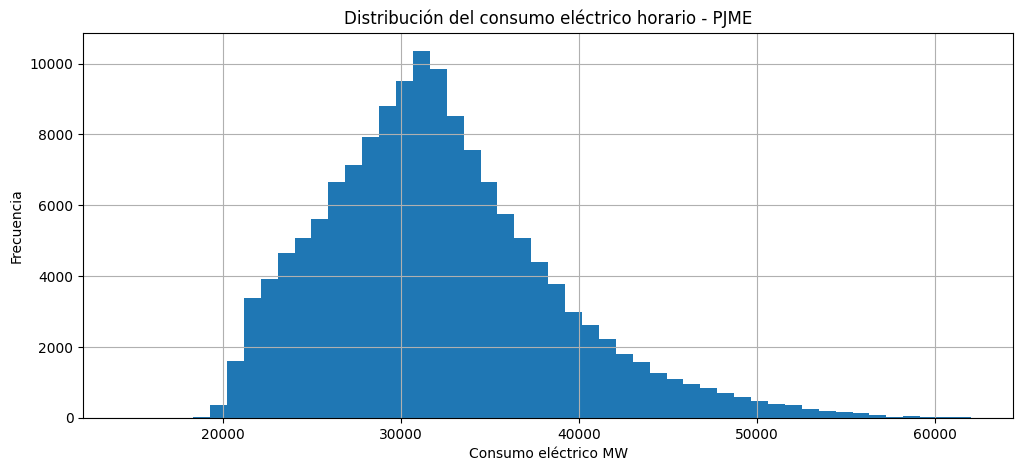

In [17]:
# ============================================================
# 16. HISTOGRAMA DEL CONSUMO ELÉCTRICO
# ============================================================

plt.figure(figsize=(12, 5))
plt.hist(df['PJME_MW'], bins=50)
plt.title('Distribución del consumo eléctrico horario - PJME')
plt.xlabel('Consumo eléctrico MW')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

El histograma permite observar la frecuencia con la que aparecen distintos niveles de consumo eléctrico.

En este tipo de series es habitual encontrar una distribución amplia, ya que la demanda varía según la hora del día, el día de la semana y la estación del año.

## 12. Patrón horario de consumo

Uno de los patrones más importantes en la demanda eléctrica es el comportamiento por hora del día.

El consumo eléctrico suele variar significativamente entre la madrugada, la jornada laboral, la tarde y la noche. Analizar este patrón permite identificar las horas de mayor y menor demanda promedio.

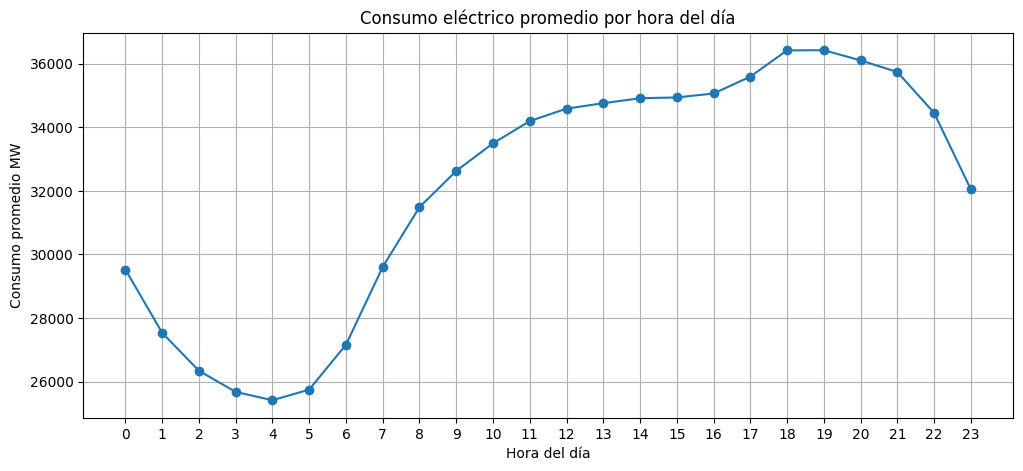

In [18]:
# ============================================================
# 17. PATRÓN PROMEDIO POR HORA DEL DÍA
# ============================================================

hourly_pattern = df.groupby('hour')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [19]:
# ============================================================
# 18. TABLA DE CONSUMO PROMEDIO POR HORA
# ============================================================

hourly_pattern_df = hourly_pattern.reset_index()
hourly_pattern_df.columns = ['hour', 'avg_demand_MW']

hourly_pattern_df.sort_values('avg_demand_MW', ascending=False).head(10)

,hour,avg_demand_MW
19,19,36426.629911
18,18,36421.931496
20,20,36106.840211
21,21,35741.057280
17,17,35596.051502
16,16,35065.392209
15,15,34940.669693
14,14,34916.601684
13,13,34759.571146
12,12,34588.618356


El análisis horario permite identificar las horas del día en que la demanda eléctrica promedio tiende a ser más alta.

Este patrón es fundamental para el modelamiento predictivo, ya que la hora del día suele ser una de las variables más relevantes en modelos de forecasting de consumo eléctrico.

## 13. Patrón semanal de consumo

Además del patrón horario, la demanda eléctrica puede presentar diferencias importantes según el día de la semana.

En muchos sistemas eléctricos, los días laborales presentan dinámicas distintas a los fines de semana debido a cambios en la actividad industrial, comercial y residencial.

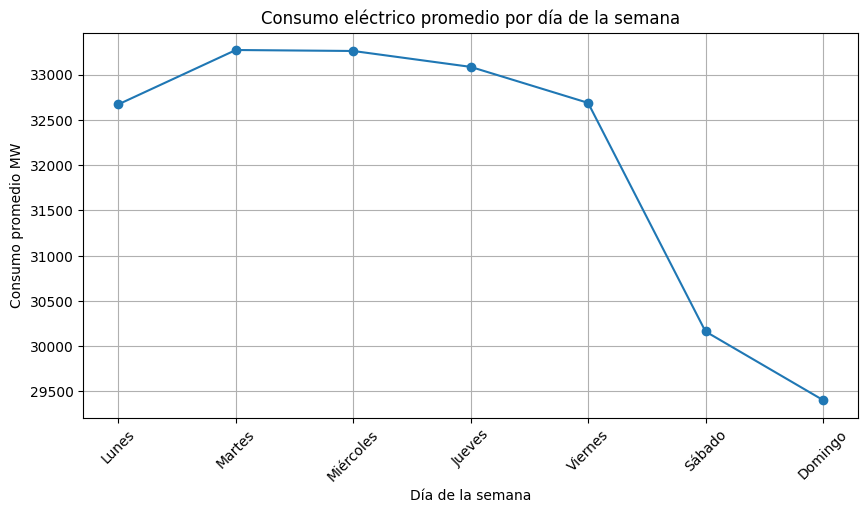

In [20]:
# ============================================================
# 19. PATRÓN PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern = df.groupby('dayofweek')['PJME_MW'].mean()

plt.figure(figsize=(10, 5))
plt.plot(weekly_pattern.index, weekly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Consumo promedio MW')
plt.xticks(
    ticks=range(0, 7),
    labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'],
    rotation=45
)
plt.grid(True)
plt.show()

In [21]:
# ============================================================
# 21. TABLA DE CONSUMO PROMEDIO POR DÍA DE LA SEMANA
# ============================================================

weekly_pattern_df = weekly_pattern.reset_index()
weekly_pattern_df.columns = ['dayofweek', 'avg_demand_MW']

day_names = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

weekly_pattern_df['day_name'] = weekly_pattern_df['dayofweek'].map(day_names)

weekly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,dayofweek,avg_demand_MW,day_name
1,1,33272.265746,Martes
2,2,33261.497498,Miércoles
3,3,33085.857727,Jueves
4,4,32688.230528,Viernes
0,0,32672.028420,Lunes
5,5,30162.880588,Sábado
6,6,29405.850409,Domingo


El patrón semanal permite comparar la demanda promedio entre días laborales y fines de semana.

Esta información es relevante porque ayuda a identificar si la serie presenta ciclos asociados a la actividad económica y social durante la semana.

## 14. Patrón mensual y estacionalidad anual

La demanda eléctrica también puede presentar patrones estacionales a lo largo del año.

Estos patrones suelen estar asociados a cambios climáticos, temperatura, uso de calefacción, aire acondicionado, actividad económica y comportamiento residencial.

En esta sección se analiza el consumo promedio por mes para identificar posibles ciclos estacionales.

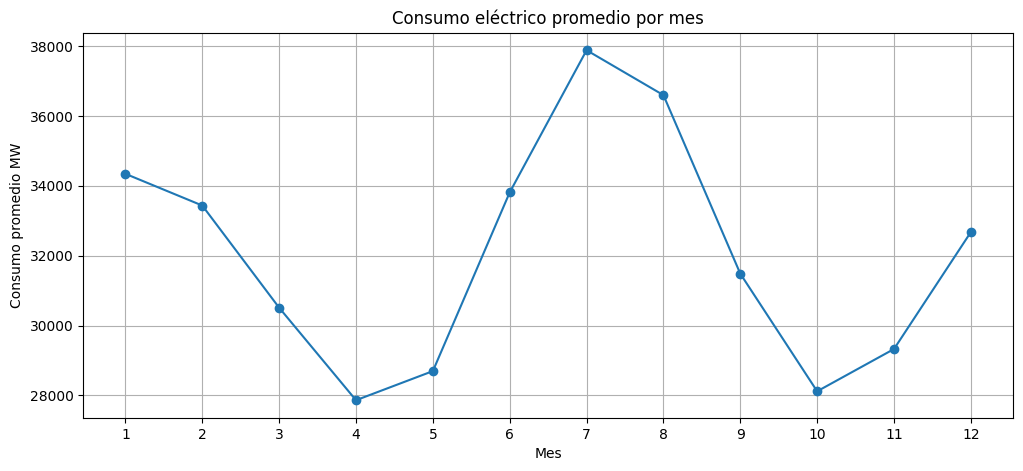

In [22]:
# ============================================================
# 22. PATRÓN PROMEDIO POR MES
# ============================================================

monthly_pattern = df.groupby('month')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por mes')
plt.xlabel('Mes')
plt.ylabel('Consumo promedio MW')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [23]:
# ============================================================
# 23. TABLA DE CONSUMO PROMEDIO POR MES
# ============================================================

monthly_pattern_df = monthly_pattern.reset_index()
monthly_pattern_df.columns = ['month', 'avg_demand_MW']

month_names = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

monthly_pattern_df['month_name'] = monthly_pattern_df['month'].map(month_names)

monthly_pattern_df.sort_values('avg_demand_MW', ascending=False)

,month,avg_demand_MW,month_name
6,7,37881.972881,Julio
7,8,36595.959675,Agosto
0,1,34343.246462,Enero
5,6,33811.799183,Junio
1,2,33434.972049,Febrero
11,12,32676.480343,Diciembre
8,9,31484.054688,Septiembre
2,3,30510.017868,Marzo
10,11,29327.692448,Noviembre
4,5,28695.362113,Mayo


El análisis mensual permite observar si existen meses con mayor demanda promedio.

En sistemas eléctricos, estos patrones suelen estar fuertemente relacionados con condiciones estacionales. Por ejemplo, los meses de verano o invierno pueden presentar mayor consumo debido al uso intensivo de sistemas de climatización.

## 15. Evolución anual de la demanda eléctrica

Además de los patrones intra-anuales, es importante analizar la evolución de la demanda a nivel anual.

Este análisis permite observar si el consumo promedio ha aumentado, disminuido o se ha mantenido relativamente estable durante el período histórico disponible.

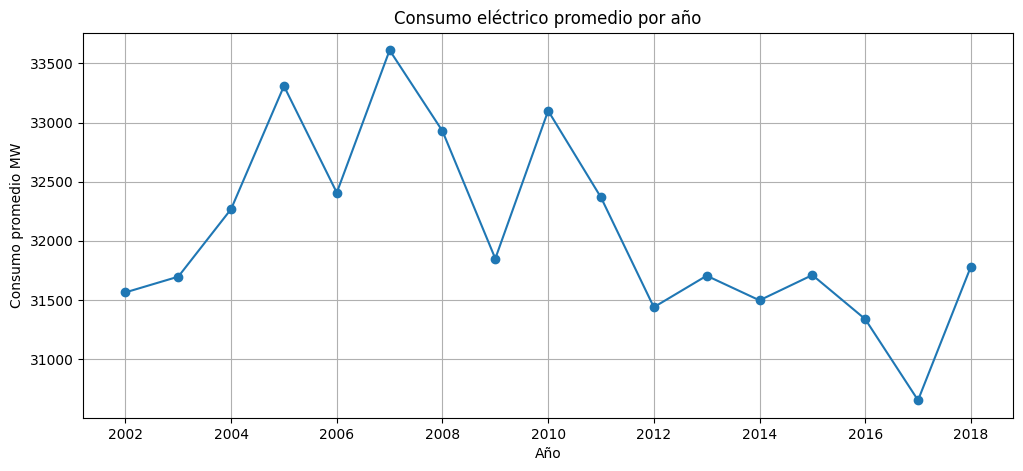

In [24]:
# ============================================================
# 24. CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern = df.groupby('year')['PJME_MW'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_pattern.index, yearly_pattern.values, marker='o')
plt.title('Consumo eléctrico promedio por año')
plt.xlabel('Año')
plt.ylabel('Consumo promedio MW')
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# 25. TABLA DE CONSUMO PROMEDIO POR AÑO
# ============================================================

yearly_pattern_df = yearly_pattern.reset_index()
yearly_pattern_df.columns = ['year', 'avg_demand_MW']

yearly_pattern_df

,year,avg_demand_MW
0,2002,31563.698539
1,2003,31696.652226
2,2004,32268.228541
3,2005,33308.357477
4,2006,32407.062842
5,2007,33611.355137
6,2008,32927.883140
7,2009,31849.275628
8,2010,33099.388014
9,2011,32366.498288


La evolución anual permite evaluar tendencias generales de largo plazo en la demanda eléctrica.

Este análisis es útil para identificar posibles cambios estructurales en el consumo, aunque para confirmar una tendencia sería necesario complementar la visualización con técnicas estadísticas o modelos específicos de series de tiempo.

## 16. Mapa de calor: hora del día vs día de la semana

Para visualizar simultáneamente el patrón horario y semanal, se construye una matriz de consumo promedio según hora del día y día de la semana.

Este tipo de visualización permite identificar franjas horarias de alta demanda y comparar si el comportamiento cambia entre días laborales y fines de semana.

In [26]:
# ============================================================
# 26. MATRIZ HORA VS DÍA DE LA SEMANA
# ============================================================

heatmap_data = df.pivot_table(
    values='PJME_MW',
    index='hour',
    columns='dayofweek',
    aggfunc='mean'
)

heatmap_data.columns = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

heatmap_data

,Lunes,Martes,Miércoles,Jueves,Viernes,Sábado,Domingo
hour,,,,,,,
0,28529.783815,29831.184971,30043.361432,30020.826790,29985.959584,29642.716763,28616.581503
1,26734.907514,27787.997691,27954.889145,27937.338337,27915.332948,27627.632370,26789.790751
2,25692.808092,26609.139723,26757.681293,26731.433025,26704.654335,26333.373410,25554.229480
3,25174.364162,25979.327945,26106.426097,26071.667436,26046.408092,25557.092486,24798.202312
4,25071.047399,25774.564665,25878.042725,25843.707852,25810.889017,25143.010405,24381.764162
5,25634.902890,26279.495381,26350.682448,26306.414550,26245.005780,25127.183815,24300.380347
6,27457.404624,28132.184758,28195.187067,28116.674365,27967.602312,25653.536416,24613.971098
7,30494.810405,31339.482679,31390.852194,31254.294457,30962.820809,26611.240462,25217.871676
8,32650.757225,33494.885681,33527.848730,33376.994226,33086.301734,28011.023121,26281.131792


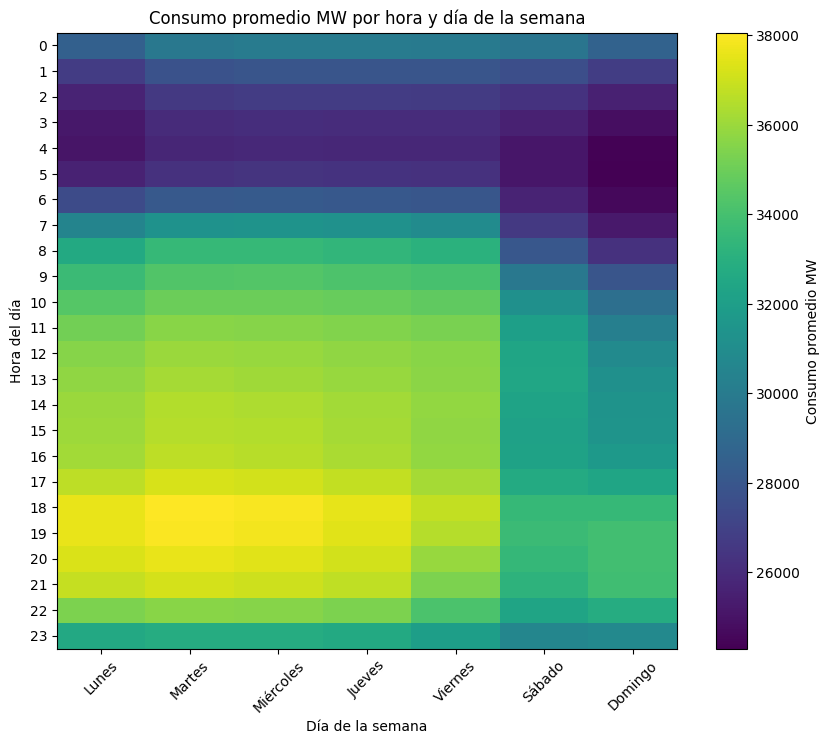

In [27]:
# ============================================================
# 27. HEATMAP HORA VS DÍA DE LA SEMANA
# ============================================================

plt.figure(figsize=(10, 8))
plt.imshow(heatmap_data, aspect='auto')
plt.title('Consumo promedio MW por hora y día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Hora del día')
plt.xticks(ticks=range(7), labels=heatmap_data.columns, rotation=45)
plt.yticks(ticks=range(24), labels=range(24))
plt.colorbar(label='Consumo promedio MW')
plt.show()

El mapa de calor permite observar de manera integrada cómo cambia la demanda eléctrica según la hora del día y el día de la semana.

Las zonas de mayor intensidad representan períodos de mayor consumo promedio, mientras que las zonas de menor intensidad reflejan períodos de menor demanda relativa.

## 17. Detección inicial de peak demand

Uno de los aspectos más relevantes en la gestión eléctrica es la identificación de períodos de alta demanda o `peak demand`.

Estos eventos son importantes porque pueden tensionar la operación del sistema eléctrico, requerir mayor capacidad de generación y afectar decisiones de planificación energética.

En esta primera aproximación se identificarán los registros que se encuentran sobre el percentil 95 de consumo.

In [28]:
# ============================================================
# 28. DEFINICIÓN DE UMBRAL DE PEAK DEMAND
# ============================================================

peak_threshold = df['PJME_MW'].quantile(0.95)

print(f"Umbral de peak demand percentil 95: {peak_threshold:,.2f} MW")

Umbral de peak demand percentil 95: 44,187.00 MW


In [29]:
# ============================================================
# 29. IDENTIFICACIÓN DE REGISTROS DE PEAK DEMAND
# ============================================================

df['is_peak_demand'] = np.where(df['PJME_MW'] >= peak_threshold, 1, 0)

peak_events = df[df['is_peak_demand'] == 1]

print("Cantidad de registros peak demand:", len(peak_events))
print("Porcentaje del total:", round(len(peak_events) / len(df) * 100, 2), "%")

peak_events.head()

Cantidad de registros peak demand: 7272
Porcentaje del total: 5.0 %


,PJME_MW,hour,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_peak_demand
Datetime,,,,,,,,,,
2002-04-17 17:00:00,44537.0,17,2,17,107,16,4,2,2002,1
2002-04-17 18:00:00,44332.0,18,2,17,107,16,4,2,2002,1
2002-06-05 15:00:00,44615.0,15,2,5,156,23,6,2,2002,1
2002-06-05 16:00:00,45533.0,16,2,5,156,23,6,2,2002,1
2002-06-05 17:00:00,46006.0,17,2,5,156,23,6,2,2002,1


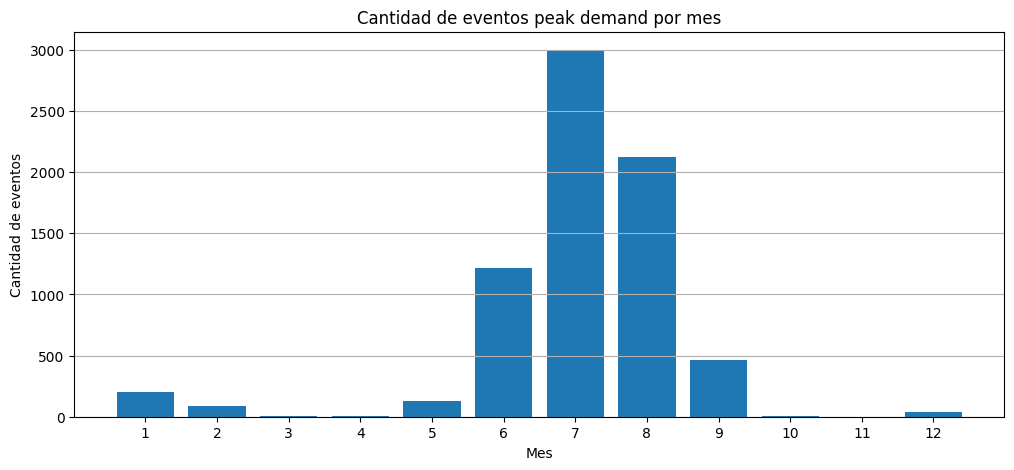

In [30]:
# ============================================================
# 30. DISTRIBUCIÓN DE PEAK DEMAND POR MES
# ============================================================

peak_by_month = peak_events.groupby('month').size()

plt.figure(figsize=(12, 5))
plt.bar(peak_by_month.index, peak_by_month.values)
plt.title('Cantidad de eventos peak demand por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de eventos')
plt.xticks(range(1, 13))
plt.grid(axis='y')
plt.show()

La detección de peak demand permite identificar los períodos donde la demanda eléctrica se ubica dentro del 5% más alto de toda la serie histórica.

Este análisis entrega una primera visión sobre la concentración temporal de los eventos de alta demanda y puede ser utilizado posteriormente para análisis de riesgo operacional, planificación de capacidad o diseño de estrategias de respuesta ante demanda.

## 18. Conclusiones preliminares del análisis exploratorio

En esta primera etapa del proyecto se realizó una exploración inicial del consumo eléctrico horario de la zona PJME.

A partir del análisis se observaron elementos clave para el desarrollo posterior del modelo predictivo:

1. La serie cuenta con una estructura temporal horaria adecuada para forecasting.
2. La demanda eléctrica presenta variabilidad relevante a lo largo del tiempo.
3. Existen patrones diferenciados según la hora del día.
4. El consumo varía según el día de la semana, lo que sugiere comportamiento asociado a ciclos laborales y residenciales.
5. La demanda promedio cambia entre meses, evidenciando posible estacionalidad anual.
6. Los eventos de peak demand pueden identificarse mediante umbrales estadísticos como el percentil 95.

Estos hallazgos justifican avanzar hacia una etapa de preparación de datos para modelamiento, incorporando variables temporales, rezagos de demanda y validación temporal.